# Beyond BLAST: generalized window functions

In [5]:
using Pkg
Pkg.activate("blast_code")
Pkg.resolve()
Pkg.instantiate()

  Activating project at `~/Desktop/cosmo/notebooks/blast_code`
  No Changes to `~/Desktop/cosmo/notebooks/blast_code/Project.toml`
  No Changes to `~/Desktop/cosmo/notebooks/blast_code/Manifest.toml`
Precompiling packages...
   3158.3 ms  ✓ blast_tutorials
  1 dependency successfully precompiled in 5 seconds. 324 already precompiled.


In [6]:
include("blast_code/src/Blast.jl")
include("blast_code/src/blast_tutorials.jl")
include("blast_code/src/new_funcs.jl")

compute_T̃_beyond (generic function with 1 method)

In [7]:
using NPZ
using DataInterpolations
using Interpolations
using FastChebInterp
using BenchmarkTools
using Plots
using QuadGK
using LaTeXStrings
using Tullio
using LoopVectorization
using LinearAlgebra
using Unitful
using Revise
using SpecialFunctions
using DifferentialEquations
using Cosmology
using .Blast
using .blast_tutorials;

In [15]:
#Background quantities
z_b = npzread("blast_code/data/background/z.npy") # array of background redshifts
χ_b = npzread("blast_code/data/background/chi.npy") # array of background comoving distances 
# this approximate the redshift z as a function of the comoving distance χ, 
# and vice versa, using Akima interpolation
z_of_χ = DataInterpolations.AkimaInterpolation(z_b, χ_b); # z(χ)
χ_of_z = DataInterpolations.AkimaInterpolation(χ_b, z_b); # χ(z)

In [16]:
# Load N5K n(z), needed to compute lensing and clustering kernels
n5k_bins = npzread("blast_code/data/dNdzs_fullwidth.npz")
#n5k_bins["dNdz_sh"]
#n5k_bins["z_sh"]
#n5k_bins["dNdz_cl"]
#n5k_bins["z_cl"]

Dict{String, Array{Float64}} with 4 entries:
  "dNdz_cl" => [9.51877e-8 1.11093e-13 … 5.97529e-61 6.25179e-67; 1.246e-7 1.56…
  "z_sh"    => [0.00583333, 0.00757837, 0.00932341, 0.0110684, 0.0128135, 0.014…
  "dNdz_sh" => [0.106801 1.52148e-9 … 6.04656e-24 7.57113e-34; 0.111443 1.76706…
  "z_cl"    => [0.00583333, 0.00757837, 0.00932341, 0.0110684, 0.0128135, 0.014…

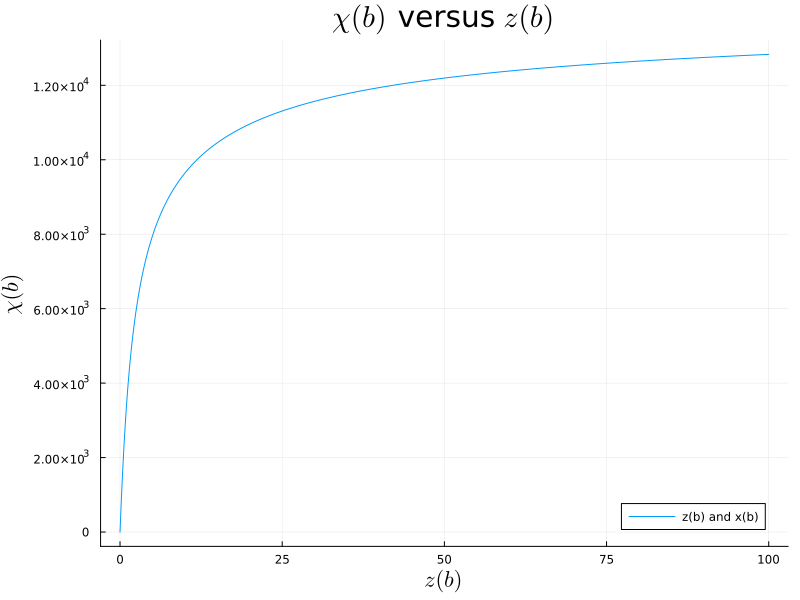

In [17]:
plot(z_b, χ_b, label="z(b) and x(b)", 
               title = L"$\chi(b)$ versus $z(b)$", 
               titlefontsize=20, 
               xlabel=L"$z(b)$", 
               ylabel=L"$\chi(b)$", 
               labelfontsize=15, 
               size=(800,600))

In [11]:
#3D matter power spectrum
pk_dict = npzread("blast_code/data/pk.npz")
Pklin = pk_dict["pk_lin"]
Pknonlin = pk_dict["pk_nl"]
k = pk_dict["k"]
z = pk_dict["z"];

In [12]:
#Interpolating the power spectrum
#Linear P(k)
# y has the same length as k, and is a logarithmic range from log10(first(k)) to log10(last(k))
y = LinRange(log10(first(k)),log10(last(k)), length(k))
# x has the same length as z, and is a linear range from first(z) to last(z)
x = LinRange(first(z), last(z), length(z))

# this creates an interpolation of the linear P(k) data. 
# the interpolatio is in log space because P(k) changes by many order or magnitude
InterpPmm = Interpolations.interpolate(log10.(Pklin),BSpline(Cubic(Line(OnGrid()))))
# this scales the interpolation to the x and y ranges defined above, 
# so that we can evaluate it at any (z, log10(k)) within those ranges
InterpPmm = scale(InterpPmm, (x, y))
# this allows us to extrapolate the interpolation outside of the defined x and y ranges
InterpPmm = Interpolations.extrapolate(InterpPmm, Line())

#Non-linear P(k) - similar to the linear P(k)
y = LinRange(log10(first(k)),log10(last(k)), length(k))
x = LinRange(first(z), last(z), length(z))
InterpPmm_nl = Interpolations.interpolate(log10.(Pknonlin),BSpline(Cubic(Line(OnGrid()))))
InterpPmm_nl = scale(InterpPmm_nl, x, y)
InterpPmm_nl = Interpolations.extrapolate(InterpPmm_nl, Line())

#Callables: these functions take in k, χ1, and χ2, 
# and return the square root of the product of the P(k) evaluated at those points.
power_spectrum(k, χ1, χ2) = @. sqrt(10^InterpPmm(z_of_χ(χ1),log10(k)) * 10^InterpPmm(z_of_χ(χ2),log10(k)))
power_spectrum_nl(k, χ1, χ2) = @. sqrt(10^InterpPmm_nl(z_of_χ(χ1),log10(k)) * 10^InterpPmm_nl(z_of_χ(χ2),log10(k)));

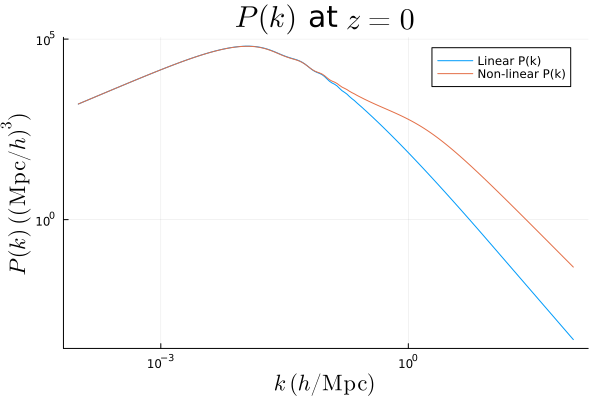

In [13]:
plot(k, power_spectrum.(k, 1000.0, 1000.0), 
     label="Linear P(k)", 
     xscale=:log10, 
     yscale=:log10, 
     title=L"$P(k)$ at $z=0$", titlefontsize=20,
     xlabel=L"$k \; (h/\mathrm{Mpc})$", 
     ylabel=L"$P(k) \; ((\mathrm{Mpc}/h)^3)$", 
     labelfontsize=15)
plot!(k, power_spectrum_nl.(k, 1000.0, 1000.0), 
      label="Non-linear P(k)", 
      xscale=:log10, 
      yscale=:log10)

In [29]:
#N5K benchmarks
dtype = Float64

benchmark_gg = npzread("blast_code/data/benchmarks_nl_full_clgg.npz")
benchmark_ll = npzread("blast_code/data/benchmarks_nl_full_clss.npz")
benchmark_gl = npzread("blast_code/data/benchmarks_nl_full_clgs.npz")

#Extracting C_ℓ
gg = dtype.(benchmark_gg["cls"])
ll = dtype.(benchmark_ll["cls"])
gl = dtype.(benchmark_gl["cls"])
ell = dtype.(benchmark_gg["ls"])

#Reshaping them into the same Blast's format
gg_reshaped = zeros( dtype, length(ell), 10, 10)
ll_reshaped = zeros(dtype, length(ell), 5, 5)
gl_reshaped = zeros( dtype, length(ell), 10, 5)
counter = 1
for i in 1:10
    for j in i:10
        gg_reshaped[:,i,j] = gg[counter, :]
        gg_reshaped[:,j,i] = gg_reshaped[:,i,j]
        counter += 1
    end
end
counter = 1
for i in 1:5
    for j in i:5
        ll_reshaped[:,i,j] = ll[counter, :]
        ll_reshaped[:,j,i] = ll_reshaped[:,i,j]
        counter += 1
    end
end
counter = 1
for i in 1:10
    for j in 1:5
        gl_reshaped[:,i,j] = gl[counter, :]
        counter += 1
    end
end

In [30]:
ℓ = Blast.ℓ
n_chi = 2 # number of comoving "bins"
x_min = 26 # minimum comoving distance
x_max = 7000 # maximum comoving distance
χ = LinRange(x_min, x_max, n_chi) # array of comoving distances
R = chebpoints(n_chi, -1, 1) # array of ratios
R = reverse(R[R.>0])
nR = length(R) # number of ratios R
kmax = 200/13 # maximum wavenumber (small scales)
kmin = 2.5/x_max # minimum wavenumber (large scales)
n_cheb = 2 # number of Chebyshev nodes 
β = 2 # exponent depending on the probe
      # 0 for Galaxy - Shear, 
      # 2 for Galaxy - Galaxy, 
      # -2 for Shear - Shear
k_cheb = chebpoints(n_cheb, log10(kmin), log10(kmax)) # number of Chebyshev "points"
# Define k' and k'' on Chebyshev grid
k1 = k2 = 10 .^ chebpoints(n_cheb, log10(kmin), log10(kmax)) # wavenumbers k' and k''
N = 2^(15)+1 # number of integration points

32769

In [31]:
# cosmo = Cosmology.cosmology(h=0.67, OmegaM=0.32, OmegaK=0.0, w0=-1.0, wa=0.0)
# z_grid = collect(range(0.0, 3.0, length=2000))
# chi_grid = ustrip.(comoving_radial_dist.(Ref(cosmo), z_grid))
# χ_of_z = linear_interpolation(z_grid, chi_grid, extrapolation_bc=Line())
# ######################################################
# # comoving distance as a function of redshift
# chi = χ_of_z.(z_grid)
# ######################################################
# # bias as a function of redshift
# b_of_z = z -> sqrt(1.0 + z)
# ######################################################
# # growth factor as a function of redshift
# H_not = 100.0 * 0.67
# E_of_z(z) = sqrt(0.32 * (1 + z)^3 + (1.0 - 0.32) * (1 + z)^0)
# H_of_z = z -> H_not * E_of_z(z)
# growth_integrand = z -> 1.0 / (H_of_z(z) * (1 + z))^3
# D_unnorm = [H_of_z(z) * quadgk(growth_integrand, z, 100.0)[1] for z in z_grid]
# D_grid   = D_unnorm ./ D_unnorm[1]   # normalize to D(z=0) = 1
# D_of_z = linear_interpolation(z_grid, D_grid, extrapolation_bc=Line())
# ######################################################
# # redshift distribution as a function of redshift
# dndz_cl = n5k_bins["dNdz_cl"][:, 1]   # choose the bin you want
# n_z = linear_interpolation(z_grid, dndz_cl, extrapolation_bc=Line());

In [32]:
"""
    cheb_coefficients_from_samples(fvals)

Compute Chebyshev coefficients from values sampled at Chebyshev/Clenshaw-Curtis nodes.
This uses the DCT-I machinery provided by FastTransforms.
"""
function cheb_coefficients_from_samples(fvals::AbstractVector)
    N = length(fvals)
    plan = FFTW.planr2r(copy(fvals), FFTW.REDFT00, 1; flags=FFTW.PATIENT)
    c = plan * collect(fvals)
    c ./= (N - 1)
    c[1]   /= 2
    c[end] /= 2
    return c
end

"""
    computeWtilde(l, χgrid, Rgrid, kmin, kmax; ncheb=120, Nk=2^15+1, α=0)

Precompute the cosmology-independent tensor W̃ for a given multipole l.

The return array has dimensions:
    (nχ, nR, ncheb+1)

Here α is the k-power prefactor:
    α = 2   for clustering
    α = -2  for shear
    α = 0   for cross terms
"""
function computeWtilde(l::Int,
                       χgrid::AbstractVector,
                       Rgrid::AbstractVector,
                       kmin::Real,
                       kmax::Real;
                       ncheb::Int = 120,
                       Nk::Int = 2^15 + 1,
                       α::Int = 0)

    k = get_clencurt_grid(kmin, kmax, Nk)

    # Chebyshev basis on k mapped to [-1,1]
    xk = (2 .* k .- (kmax + kmin)) ./ (kmax - kmin)

    # Precompute Chebyshev polynomials T_n(x_k)
    Tnk = zeros(Float64, ncheb + 1, Nk)
    Tnk[1, :] .= 1.0
    if ncheb >= 1
        Tnk[2, :] .= xk
    end
    for n in 2:ncheb
        Tnk[n+1, :] .= 2 .* xk .* Tnk[n, :] .- Tnk[n-1, :]
    end

    nχ = length(χgrid)
    nR = length(Rgrid)
    Wtilde = zeros(Float64, nχ, nR, ncheb + 1)

    Threads.@threads for iχ in 1:nχ
        χ = χgrid[iχ]
        for iR in 1:nR
            R = Rgrid[iR]

            jl1 = sphericalbesselj.(l, k .* χ)
            jl2 = sphericalbesselj.(l, k .* χ .* R)

            # Weight corresponding to the k-dependence in the Blast integrand
            wk = k .^ α

            for n in 1:(ncheb + 1)
                integrand = wk .* jl1 .* jl2 .* Tnk[n, :]
                Wtilde[iχ, iR, n] = clenshaw_curtis_integral(k, integrand)
            end
        end
    end

    return Wtilde
end

"""
    clenshaw_curtis_integral(x, y)

Simple quadrature on a Clenshaw-Curtis grid using rescaled weights.
If you already have the Blast precomputed weights, use those instead.
"""
function clenshaw_curtis_integral(x::AbstractVector, y::AbstractVector)
    N = length(x)
    w = clenshaw_curtis_weights(N)
    return sum(w .* y)
end

function clenshaw_curtis_weights(N::Int)
    # Placeholder: for production use the FastTransforms weights on the mapped interval.
    # This version is intentionally simple and easy to replace.
    w = ones(Float64, N)
    w[1] *= 0.5
    w[end] *= 0.5
    return w / (N - 1)
end

"""
    compute_cheb_coefficients(Pk, kmin, kmax)

Given a function Pk(k), sample it on a Chebyshev grid and return coefficients c_n.
"""
function compute_cheb_coefficients(Pk::Function, kmin::Real, kmax::Real; N::Int = 121)
    k = get_clenshaw_curtis_grid(kmin, kmax, N)
    vals = Pk.(k)
    return cheb_coefficients_from_samples(vals)
end

"""
    contract_Wtilde_c(Wtilde, c)

Contract the precomputed W̃ tensor with the Chebyshev coefficients c.
The output has dimensions (nχ, nR).
"""
function contract_Wtilde_c(Wtilde::AbstractArray, c::AbstractVector)
    @tullio W[i, j] := Wtilde[i, j, n] * c[n]
    return W
end


contract_Wtilde_c

In [33]:
Pk(k) = k^0 * exp(-k/0.2)   # example power spectrum shape

kmin, kmax = 1e-4, 10.0
c = compute_cheb_coefficients(Pk, kmin, kmax; N=121)

χgrid = range(10.0, 3000.0, length=50) |> collect
Rgrid = range(0.01, 1.0, length=40) |> collect

Wtilde = computeWtilde(2, χgrid, Rgrid, kmin, kmax; ncheb=120, Nk=2^15+1, α=0)

W = contract_Wtilde_c(Wtilde, c)

LoadError: UndefVarError: `FastTransforms` not defined

In [34]:
function compute_W̃(ℓ::Integer,
                    k::AbstractVector,
                    k2::AbstractVector,
                    z_min::Number,
                    z_max::Number,
                    chi,
                    b_of_z,
                    n_z,
                    D_of_z;
                    N::Int = 2^(15) + 1)

    z     = Blast.get_clencurt_grid(z_min, z_max, N)
    w     = Blast.get_clencurt_weights(z_min, z_max, N)
    cw     = cosmo_weight(chi, b_of_z.(z), n_z.(z), D_of_z.(z))
    weight = w .* cw

    W̃ = zeros(length(k), length(k2))

    Threads.@threads for i in eachindex(k)
        jl_k = SpecialFunctions.sphericalbesselj.(ℓ, k[i]  .* chi)   # length-N vector
        for j in eachindex(k2)
            jl_k2 = SpecialFunctions.sphericalbesselj.(ℓ, k2[j] .* chi)
            W̃[i, j] = sum(weight .* jl_k .* jl_k2)
        end
    end

    return W̃
end


# Compute W̃ for each ℓ value
W_LL = zeros(length(ℓ), length(k1), length(k2))

z_min = first(z_b)
z_max = last(z_b)

Threads.@threads for i in eachindex(ℓ)
    W_LL[i, :, :] = compute_W̃(ℓ[i], k1, k2, z_min, z_max, chi, b_of_z, n_z, D_of_z; N=N)
    println("W̃ for probe A: step ", [i], " out of [", length(ℓ) ,"] completed")
end

LoadError: TaskFailedException

[91m    nested task error: [39mUndefVarError: `chi` not defined
    Stacktrace:
     [1] [0m[1mmacro expansion[22m
    [90m   @[39m [90m./[39m[90m[4mIn[34]:38[24m[39m[90m [inlined][39m
     [2] [0m[1m(::var"#782#threadsfor_fun#44"{var"#782#threadsfor_fun#43#45"{Base.OneTo{Int64}}})[22m[0m[1m([22m[90mtid[39m::[0mInt64; [90monethread[39m::[0mBool[0m[1m)[22m
    [90m   @[39m [36mMain[39m [90m./[39m[90m[4mthreadingconstructs.jl:215[24m[39m
     [3] [0m[1m#782#threadsfor_fun[22m
    [90m   @[39m [90m./[39m[90m[4mthreadingconstructs.jl:182[24m[39m[90m [inlined][39m
     [4] [0m[1m(::Base.Threads.var"#1#2"{var"#782#threadsfor_fun#44"{var"#782#threadsfor_fun#43#45"{Base.OneTo{Int64}}}, Int64})[22m[0m[1m([22m[0m[1m)[22m
    [90m   @[39m [90mBase.Threads[39m [90m./[39m[90m[4mthreadingconstructs.jl:154[24m[39m

In [ ]:
print("Shape of the computed W̃_A: ", size(W_LL), "\n")
println(W_LL)

Shape of the computed W̃_A: (22, 3, 3)
[0.021131602738469268 -0.0035637369875745825 2.190698337931635e-6; 0.02112333511280047 0.0005590237669675399 -3.229479124465256e-8; 0.021131685538527983 -0.0023292632048289353 -5.551473212418056e-11; 0.02112459963430791 -6.440156080428458e-5 -4.221454933754484e-19; 0.021131265448342446 0.00038005164722226326 1.765486127285616e-26; 0.021127349485977297 7.163776501848713e-7 1.2935329637581647e-39; 0.021127141259016925 -6.781486319039492e-10 -3.0293569242715936e-55; 0.021128720538573547 4.313727492723646e-15 2.959820762409724e-75; 0.02111476493428453 1.142282700237253e-21 7.438887019164604e-99; 0.02111461058919626 5.1470157320786954e-30 2.011787407340226e-126; 0.02111464629627923 4.884699814389163e-41 7.501678182782964e-159; 0.021110991963002528 -8.246164024866724e-53 -3.376669410189096e-194; 0.021095261852155527 -2.851063369271046e-66 -2.2285524455061185e-233; 0.021087899642739345 -1.3667368163203868e-82 -1.5448154302030675e-277; 0.02107679224493349

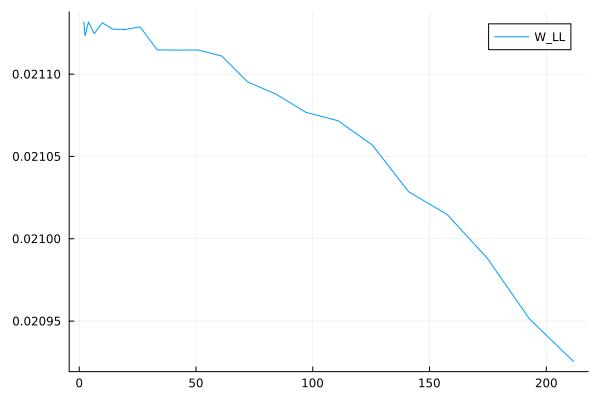

In [201]:
i1 = 1
i2 = 1
plot(ℓ, W_LL[:,i1,i2], label="W_LL")

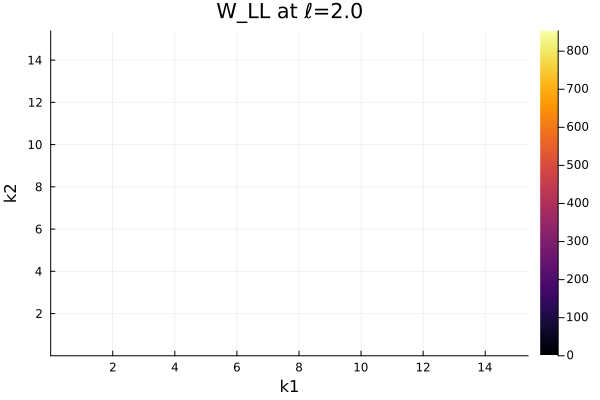

x points not sorted in ascending order
x points not sorted in ascending order
x points not sorted in ascending order


In [202]:
ell_idx = 1
heatmap(k1, k2, W_LL[ell_idx, :, :]', xlabel="k1", ylabel="k2", title="W_LL at ℓ=$(ℓ[ell_idx])")

In [188]:
function compute_Sℓ(WA::AbstractMatrix, WB::AbstractMatrix, kgrid::AbstractVector, χ1::Number, χ2::Number, Pk)
    w = Blast.get_clencurt_weights(first(kgrid), last(kgrid), length(kgrid))
    P = power_spectrum.(kgrid, χ1, χ2)
    @tullio S[a, b] := w[n] * kgrid[n]^2 * P[n] * WA[n, a] * WB[n, b]
end

kgrid = k1
S_LL = zeros(length(ℓ), size(W_LL, 2), size(W_LL_prime, 3))
for i in eachindex(ℓ)
    S_LL[i, :, :] = compute_Sℓ(W_LL[i, :, :], W_LL_prime[i, :, :], kgrid, x_min, x_max, power_spectrum_nl)
end

In [189]:
#@benchmark compute_Sℓ(W_LL[1, :, :], W_LL_prime[1, :, :], k1, x_min, x_max, power_spectrum_nl)

In [190]:
print("Shape of the computed S(l): ", size(S_LL), "\n")

Shape of the computed S(l): (22, 3, 3)
